In [1]:
import os          # File-system operations (path checks, makedirs)
import subprocess  # Run external processes (xschem, ngspice)
import re          # Regular expressions — parse ngspice measurement output
import numpy as np # Numerical arrays for waveform data

SCH_NAME = 'tb_Kickback_noise'

# ── Project paths (inside the iic-osic-tools Docker container) ───────────────
PDK_PATH = '/foss/pdks/gf180mcuD'


# Destination for the XSchem-generated netlist (.spice)
# NOTE: Without the '-o' flag, XSchem defaults to:
#   /headless/.xschem/simulations/tb_strongARM_offset.spice
# Cell 3 uses '-o SIM_DIR' to redirect output here.
#  Depending on the configuration, I sometimes use this path:
#'/foss/designs/Chipathon-2026-OnChipSAR/designs/sar_adc/comparator/Testbench/simulation/'
SIM_DIR = '/headless/.xschem/simulations'

# Directory where ngspice writes the ASCII raw waveform file
RAW_DIR = '/headless/.xschem/simulations'

# Create the raw directory if it does not already exist
os.makedirs(RAW_DIR, exist_ok=True)


In [2]:
class NgspiceRawReader:
    # Minimal ASCII raw-file reader for ngspice transient simulations.
    # When '.control / set filetype=ascii / .endc' is used in the netlist,
    # ngspice writes waveform data in a plain-text 'raw' format. This class
    # parses that file and exposes each signal as a NumPy array.

    def __init__(self, filepath):
        self.filepath  = filepath   # Absolute path to the .raw file
        self.variables = []         # Ordered list of signal names, e.g. 'v(clk)'
        self.data      = {}         # Dict: signal_name -> NumPy float array
        self.load()                 # Parse immediately on construction

    def load(self):
        # Fail early with a clear message if the file is missing
        if not os.path.exists(self.filepath):
            raise FileNotFoundError(f"Raw file not found: {self.filepath}")

        with open(self.filepath, 'r') as f:
            lines = f.readlines()

        # ── Step 1: parse the Variables: block ───────────────────────────────
        # Format:  <index>  <signal_name>  <type>   (one line per signal)
        data_start = 0
        j = 0
        for idx, line in enumerate(lines):
            if line.startswith('Variables:'):
                j = idx + 1
                while not lines[j].startswith('Values:'):
                    parts = lines[j].strip().split()
                    if len(parts) >= 3:
                        self.variables.append(parts[1])  # Keep only the name
                    j += 1
            if line.startswith('Values:'):
                data_start = j + 1  # Numeric data starts one line after 'Values:'
                break

        # ── Step 2: allocate an empty list for each signal ────────────────────
        for var in self.variables:
            self.data[var] = []

        # ── Step 3: parse the data block ─────────────────────────────────────
        # Each time-point is written as:
        #   <point_index>  <time_value>   <- first line (two tokens)
        #   <signal_1_value>              <- one per subsequent line
        i = data_start
        while i < len(lines):
            line = lines[i].strip()
            if not line:
                i += 1
                continue
            parts = line.split()
            if len(parts) == 2:   # First row of a new time-point
                self.data[self.variables[0]].append(float(parts[1]))  # time
                for v_idx in range(1, len(self.variables)):
                    self.data[self.variables[v_idx]].append(float(lines[i + v_idx].strip()))
                i += len(self.variables)
            else:
                i += 1

        # ── Step 4: convert Python lists to NumPy arrays ──────────────────────
        for var in self.variables:
            self.data[var] = np.array(self.data[var])

    def get_signal(self, name):
        # Return the NumPy array for a signal by name (case-insensitive).
        for var in self.variables:
            if var.lower() == name.lower():
                return self.data[var]
        raise KeyError(f"Signal '{name}' not found. Available: {self.variables}")

In [3]:
import re
import os
import subprocess


# Original netlist generated by XSchem 
spice_file_orig = os.path.join(SIM_DIR, f'{SCH_NAME}.spice')

# Temporary copy with the .control block appended — deleted immediately after the run
spice_file_run  = f'/tmp/{SCH_NAME}_run.spice'

# Output raw waveform file written by ngspice in ASCII format
raw_file = os.path.join(RAW_DIR, f'{SCH_NAME}.raw')

VALID_CORNERS = ('typical', 'ff', 'ss', 'fs', 'sf')

def run_simulation(w_val=None, sweep_transistors=None, corner='typical', vdd=3.3, temp=27):
    with open(spice_file_orig, 'r') as f:
        spice_code = f.read()

    # Corner swap (modifies typical corner to the selected process corner)
    pattern_corner = r"(\.lib\s+'[^']+'\s+)(\S+)"
    spice_code_new, n_corner = re.subn(pattern_corner, r'\g<1>' + corner, spice_code, flags=re.IGNORECASE)
    if n_corner == 0:
        raise RuntimeError("No .lib line with single quotes was found.")

    # Width sweep substitution
    if w_val is not None and sweep_transistors is not None:
        for tx in sweep_transistors:
            spice_code_new = re.sub(rf'({tx}\s+.*?\s+W=)\S+', r'\g<1>' + f'{w_val}u', spice_code_new)

    control_code = (
        "\n.control\n"
        "  set filetype=ascii\n"
        f"  alterparam VDD = {vdd}\n"
        "  reset\n"
        f"  option temp={temp}\n"
        "  run\n"
        f"  write {raw_file}\n"
        "  quit\n"
        ".endc\n"
    )

    with open(spice_file_run, 'w') as f:
        f.write(spice_code_new + "\n" + control_code)

    res = subprocess.run(
        ['/foss/tools/ngspice/bin/ngspice', '-b', spice_file_run],
        capture_output=True, text=True, check=True
    )

    try:
        os.remove(spice_file_run)
    except Exception:
        pass

    return res.stdout

# Run default typical simulation to keep Cell 3 (plotting/waveforms) fully functional
print("Running default typical simulation...")
sim_stdout = run_simulation()
print("Typical simulation finalized.")


Running default typical simulation...
Typical simulation finalized.



>>> Ruido de KicikBack: 0.095 uV


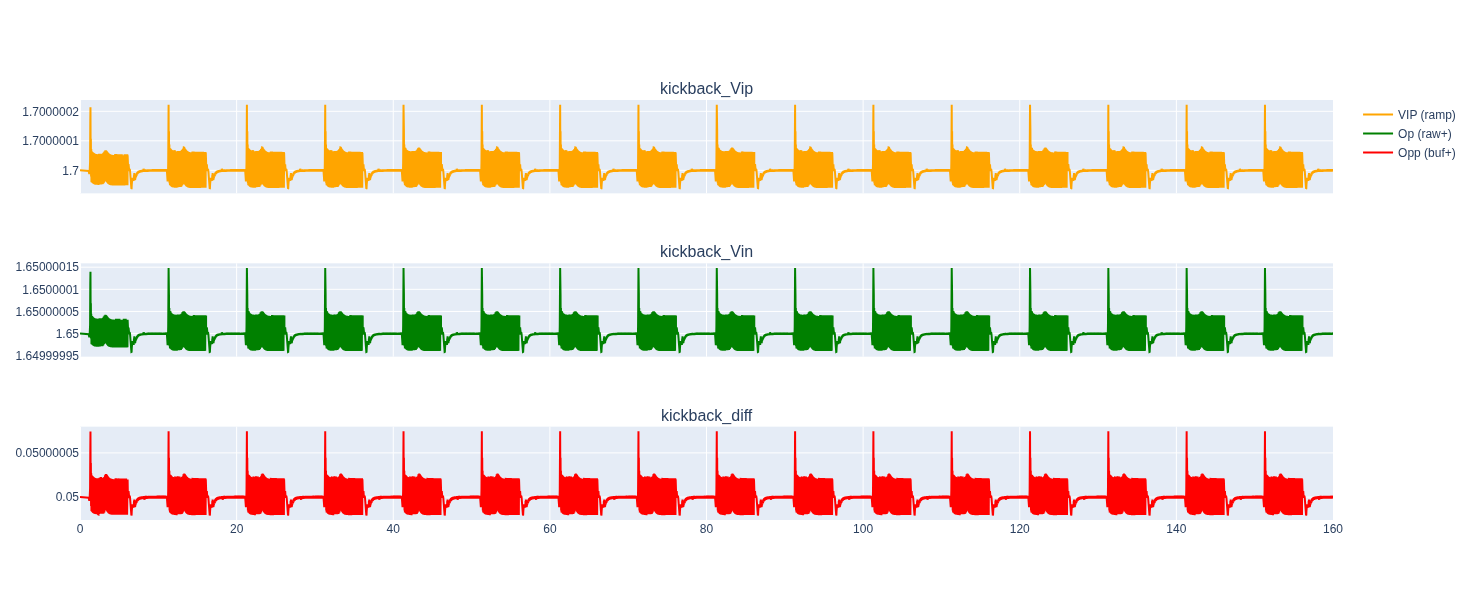

In [4]:
import re
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Parse average power from the cached ngspice output ───────────────────────kickback_diff_pkpk
# ngspice prints:  p_avg  =  1.34392e-04  (in watts)
pavg_match = re.search(r'kickback_diff_pkpk\s*=\s*([0-9e.+\-]+)', sim_stdout, re.IGNORECASE)
if pavg_match:
    pavg_val = float(pavg_match.group(1)) * 1e6   # W -> uW
    print(f"\n>>> Ruido de KicikBack: {pavg_val:.3f} uV")
else:
    print("\nWarning: 'kickback_diff_pkpk\' not found in ngspice output.")



reader = NgspiceRawReader(raw_file)
time   = reader.get_signal('time') * 1e9      # ns
# i(v1) convention: positive = current into V+ terminal of source
# Negate to get current delivered to the circuit, scale to uA
vvin   = reader.get_signal('v(vin)')  
vvip   = reader.get_signal('v(vip)')        

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,   # Synchronized zoom across all panels
    subplot_titles=(
        'kickback_Vip',
        'kickback_Vin',
        'kickback_diff'
    )
)


fig.add_trace(go.Scatter(x=time, y=vvip, name='VIP (ramp)',
                         line=dict(color='orange', width=2)), row=1, col=1)

# Panel 2: raw latch nodes
fig.add_trace(go.Scatter(x=time, y=vvin, name='Op (raw+)',
                         line=dict(color='green')),  row=2, col=1)


# Panel 3: digital outputs after the 10-stage inverter chain
fig.add_trace(go.Scatter(x=time, y=vvip-vvin, name='Opp (buf+)',
                         line=dict(color='red')),  row=3, col=1)


fig.update_layout(hovermode='x unified', height=600, width=1000)
fig.show()


Sweeping width of ['XM3', 'XM4'] from 0.5u to 10.0u...
  W = 0.50u -> VIP KB: 0.285 uV | VIN KB: 0.190 uV | Diff KB: 0.095 uV
  W = 1.00u -> VIP KB: 0.443 uV | VIN KB: 0.296 uV | Diff KB: 0.147 uV
  W = 2.00u -> VIP KB: 0.648 uV | VIN KB: 0.436 uV | Diff KB: 0.213 uV
  W = 3.00u -> VIP KB: 0.819 uV | VIN KB: 0.548 uV | Diff KB: 0.271 uV
  W = 4.00u -> VIP KB: 1.015 uV | VIN KB: 0.681 uV | Diff KB: 0.334 uV
  W = 5.00u -> VIP KB: 1.209 uV | VIN KB: 0.810 uV | Diff KB: 0.399 uV
  W = 6.00u -> VIP KB: 1.389 uV | VIN KB: 0.934 uV | Diff KB: 0.457 uV
  W = 8.00u -> VIP KB: 1.698 uV | VIN KB: 1.142 uV | Diff KB: 0.560 uV
  W = 10.00u -> VIP KB: 1.947 uV | VIN KB: 1.303 uV | Diff KB: 0.660 uV


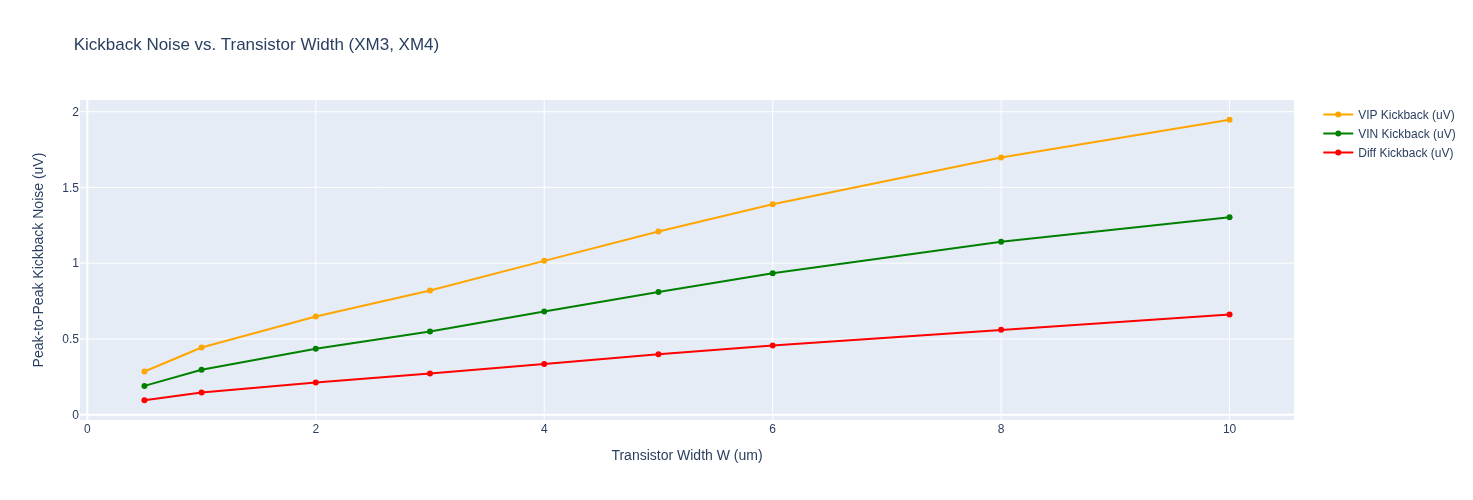

In [5]:
# ── Sweep Transistor Width ───────────────────────────────────────────────
# You can choose which transistor(s) to sweep in this list variable:
SWEEP_TRANSISTORS = ['XM3', 'XM4'] # ]# input PMOS differential pair of strongARM

# Define the width values to sweep (in micrometers):
W_VALUES = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]

print(f"Sweeping width of {SWEEP_TRANSISTORS} from {W_VALUES[0]}u to {W_VALUES[-1]}u...")

vip_kb_list = []
vin_kb_list = []
diff_kb_list = []

def parse_metric(pattern, text):
    m = re.search(pattern + r'\s*=\s*([0-9e.+\-]+)', text, re.IGNORECASE)
    return float(m.group(1)) if m else None

for w in W_VALUES:
    stdout = run_simulation(w_val=w, sweep_transistors=SWEEP_TRANSISTORS)
    
    vip_kb = parse_metric(r'kickback_VIP_pkpk', stdout)
    vin_kb = parse_metric(r'kickback_VIN_pkpk', stdout)
    diff_kb = parse_metric(r'kickback_diff_pkpk', stdout)
    
    # Convert to uV
    vip_kb_list.append(vip_kb * 1e6 if vip_kb is not None else None)
    vin_kb_list.append(vin_kb * 1e6 if vin_kb is not None else None)
    diff_kb_list.append(diff_kb * 1e6 if diff_kb is not None else None)
    
    print(f"  W = {w:.2f}u -> VIP KB: {vip_kb_list[-1]:.3f} uV | VIN KB: {vin_kb_list[-1]:.3f} uV | Diff KB: {diff_kb_list[-1]:.3f} uV")

# Plot kickback noise vs Width using Plotly
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=W_VALUES, y=vip_kb_list, name='VIP Kickback (uV)', mode='lines+markers', line=dict(color='orange', width=2)))
fig.add_trace(go.Scatter(x=W_VALUES, y=vin_kb_list, name='VIN Kickback (uV)', mode='lines+markers', line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(x=W_VALUES, y=diff_kb_list, name='Diff Kickback (uV)', mode='lines+markers', line=dict(color='red', width=2)))

fig.update_layout(
    title=f"Kickback Noise vs. Transistor Width ({', '.join(SWEEP_TRANSISTORS)})",
    xaxis_title="Transistor Width W (um)",
    yaxis_title="Peak-to-Peak Kickback Noise (uV)",
    hovermode='x unified',
    height=500, width=800
)
fig.show()
